# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

**Role:** Junior Data Scientist at a mid-sized analytics firm

New clients arrive with very different problems. In this notebook I work through **three projects** that
represent the variety of work a junior data scientist encounters:

| Part | Problem | Data | Goal |
| ---- | ------- | ---- | ---- |
| 1 | **NLP** | Customer review text | Clean text, explore language patterns so the support team can route issues |
| 2 | **Time Series** | Review timestamps | Understand trends in review activity and forecast future volume |
| 3 | **Neural Networks** | Review text -> rating | Predict the star rating a customer will give so issues are prioritized |

Even though the data and techniques differ, the **same problem-solving mindset** applies:
collect -> clean -> explore -> model -> evaluate -> interpret for the business.

---

## Part 1: Natural Language Processing (NLP)

**Connect to the scenario:** The support team receives a large stream of customer reviews.
Before any routing or automation can happen, we need to understand *what customers are writing about*.
This part cleans the free-form text and explores its language patterns.

**Plan:**
1. Load and explore the text data
2. Build a preprocessing pipeline (lowercase, URL/punctuation removal, tokenization, stopwords, lemmatization)
3. Measure token frequencies and n-grams
4. Visualize and interpret the language patterns

In [ ]:
# =============================================
# Part 1: NLP - Imports
# =============================================

# --- Data handling -----------------------------------------
import numpy as np
import pandas as pd

# --- Plotting ----------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# --- Text utilities ----------------------------------------
import re
import string
from collections import Counter

# --- NLTK: the standard toolkit for text NLP in Python ----
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

# Professional, readable plot styling
sns.set_theme()
plt.rcParams['figure.dpi'] = 100

# Reproducibility
np.random.seed(42)

In [ ]:
# =============================================
# Download the NLTK language resources we need
# =============================================
# NOTE:  If the packages are already downloaded this runs silently.
# - punkt_tab : word-tokenizer models
# - stopwords : common words (the, and, is...) we filter out later
# - wordnet   : dictionary used by the lemmatizer
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [ ]:
# =============================================
# 1. Load the dataset
# =============================================
# The file is provided as part of the lab.
df = pd.read_csv('amazon_reviews_lab.csv')

print('Dataset shape:', df.shape)
print('\nColumn names:', list(df.columns))
print('\nData types:')
print(df.dtypes)

Dataset shape: (997, 9)

Column names: ['product_id', 'rating', 'review_text', 'review_summary', 'review_time_raw', 'unix_review_time', 'timestamp', 'sentiment_label', 'review_length_words']

Data types:
product_id                 str
rating                   int64
review_text                str
review_summary             str
review_time_raw            str
unix_review_time       float64
timestamp                  str
sentiment_label            str
review_length_words      int64
dtype: object


In [ ]:
# =============================================
# 2. Explore the dataset
# =============================================
# First 3 rows to build intuition about what the text looks like
df.head(3)

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60


In [ ]:
print('--- Rating distribution (1 = worst, 5 = best) ---')
print(df['rating'].value_counts().sort_index())

print('\n--- Sentiment label distribution ---')
print(df['sentiment_label'].value_counts())

print('\n--- Review length (words) summary ---')
print(df['review_length_words'].describe())

print('\nMissing values per column:')
print(df.isnull().sum())

--- Rating distribution (1 = worst, 5 = best) ---
rating
1     87
2     48
3     94
4    188
5    580
Name: count, dtype: int64

--- Sentiment label distribution ---
sentiment_label
positive    768
negative    135
neutral      94
Name: count, dtype: int64

--- Review length (words) summary ---
count     997.000000
mean      146.374122
std       216.126770
min         5.000000
25%        32.000000
50%        67.000000
75%       165.000000
max      2079.000000
Name: review_length_words, dtype: float64

Missing values per column:
product_id             0
rating                 0
review_text            0
review_summary         0
review_time_raw        0
unix_review_time       0
timestamp              0
sentiment_label        0
review_length_words    0
dtype: int64


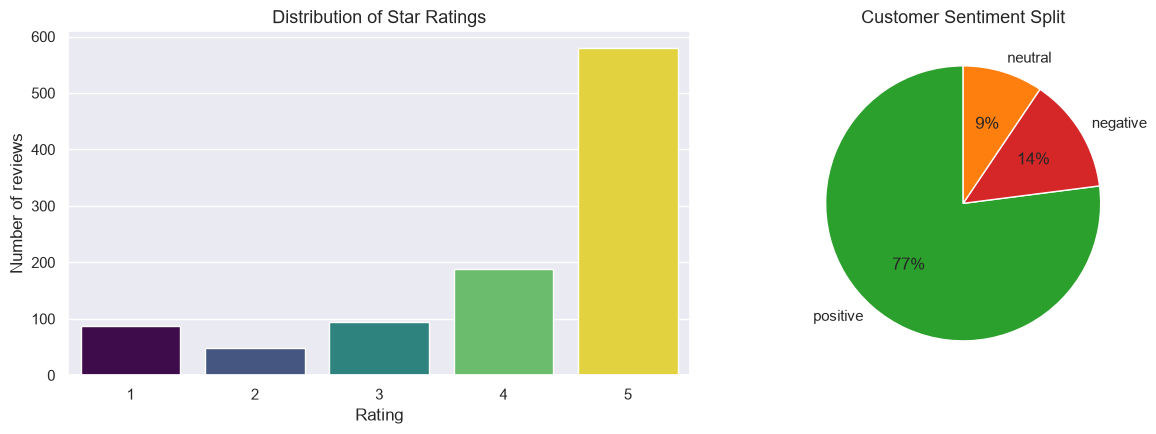

In [ ]:
# =============================================
# 3a. Visualize rating distribution
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Bar chart of star ratings
order = sorted(df['rating'].unique())
sns.countplot(data=df, x='rating', order=order, ax=axes[0], palette='viridis', hue='rating', legend=False)
axes[0].set_title('Distribution of Star Ratings', fontsize=13)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of reviews')

# Pie chart of sentiment labels
sent_vals = df['sentiment_label'].value_counts()
axes[1].pie(sent_vals.values, labels=sent_vals.index, autopct='%1.0f%%',
            colors=['#2ca02c', '#d62728', '#ff7f0e'], startangle=90)
axes[1].set_title('Customer Sentiment Split', fontsize=13)

plt.tight_layout()
plt.show()

# BUSINESS NOTE:
# ~76% of reviews are positive. Any classifier must handle this
# imbalance or it will simply predict 'positive' and look accurate.

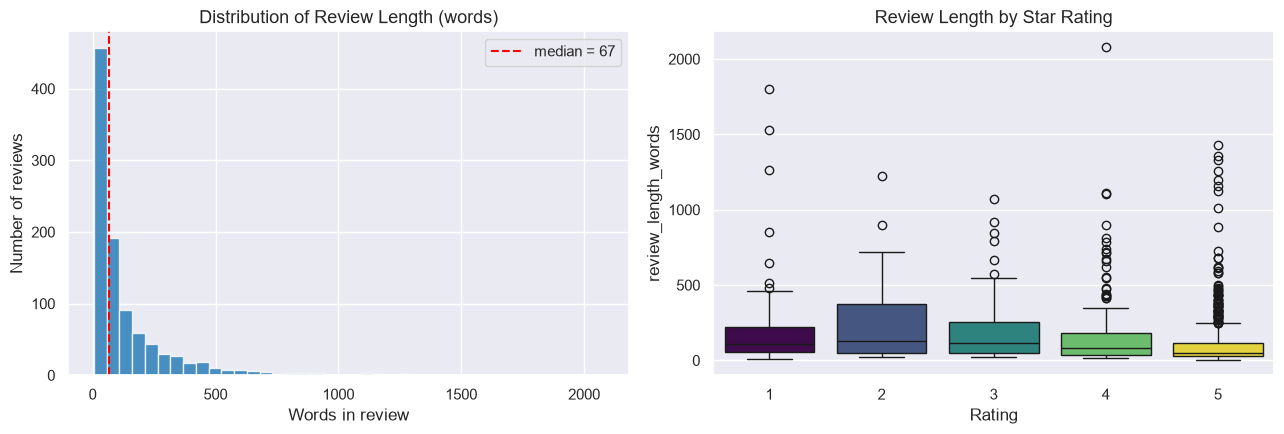

In [ ]:
# =============================================
# 3b. Visualize review length behaviour
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram of word counts (most reviews are short)
axes[0].hist(df['review_length_words'], bins=40, color='#1f77b4', alpha=0.8)
axes[0].set_title('Distribution of Review Length (words)', fontsize=13)
axes[0].set_xlabel('Words in review')
axes[0].set_ylabel('Number of reviews')
axes[0].axvline(df['review_length_words'].median(), color='red', ls='--', lw=1.5,
                label=f"median = {df['review_length_words'].median():.0f}")
axes[0].legend()

# Boxplot: does rating correlate with how much people write?
sns.boxplot(data=df, x='rating', y='review_length_words', hue='rating', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Review Length by Star Rating', fontsize=13)
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# 4. Preprocessing pipeline
# =============================================
# We clean raw text BEFORE any counting/modeling so that:
#  - token counts are comparable across documents
#  - the model is not fooled by URL fragments or punctuation
#  - rare spelling variants ('Review' vs 'review') collapse together

# Stopword list and lemmatizer are created once, then reused for speed
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Clean a raw review and return a list of cleaned tokens.

    Pipeline (in order):
      1. convert to lowercase            -> 'Music' and 'music' match
      2. remove URLs                     -> 'http://amzn.to/x' carries no signal
      3. remove punctuation + numbers    -> keep alphabetic words only
      4. tokenize into words
      5. remove stopwords                -> keep meaning-bearing words only
      6. lemmatize tokens                -> 'running', 'runs' -> 'run'
    """
    # 1 + 2. Lowercase, cut out URLs
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 3. Remove non-alphabetic characters (punctuation, digits, symbols)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Tokenize
    tokens = word_tokenize(text)

    # 5. Optional stopword removal
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]

    # 5b. Drop single-letter tokens - e.g. 'n' and 'b' are HTML residue
    #     from sanitised ampersands, they carry no meaning
    tokens = [t for t in tokens if len(t) > 1]

    # 6. Optional lemmatization
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

# Apply preprocessing to every review
df['processed_tokens'] = df['review_text'].apply(preprocess_text)

# Sanity check: show before -> after for one review
example_idx = 3
print('RAW   :', df['review_text'][example_idx][:220], '...')
print('\nCLEANED:', df['processed_tokens'][example_idx][:25], '...')

RAW   : The advertisment for this DVD on Amazon was incorrect. The ad stated that the DVD was in Wide Screen Anamorphic format. The DVD was not in this format, it was standard Pan and Scan, and it was a poor quality transfer fro ...

CLEANED: ['advertisment', 'dvd', 'amazon', 'incorrect', 'ad', 'stated', 'dvd', 'wide', 'screen', 'anamorphic', 'format', 'dvd', 'format', 'standard', 'pan', 'scan', 'poor', 'quality', 'transfer', 'film', 'thought', 'returning', 'decided', 'give', 'gift'] ...


In [ ]:
# =============================================
# 5. Verify the preprocessing quality
# =============================================
# After cleaning we expect:
#  - only alphabetic, lowercase tokens
#  - an average token count smaller than the raw word count (stopwords removed)
tokens_per_doc = df['processed_tokens'].apply(len)

print('Mean raw words per review  :', round(df['review_length_words'].mean(), 1))
print('Mean cleaned tokens/review :', round(tokens_per_doc.mean(), 1))
print('Std dev of cleaned tokens :', round(tokens_per_doc.std(), 1))
print('Unique tokens after cleaning:', len(set(t for doc in df['processed_tokens'] for t in doc)))

# Quick assertion-style check: no leftovers of punctuation-only noise tokens
noise = [t for doc in df['processed_tokens'] for t in doc if not t.isalpha()]
print('Non-alphabetic tokens left behind:', len(noise))

Mean raw words per review  : 146.4
Mean cleaned tokens/review : 71.8
Std dev of cleaned tokens : 107.0
Unique tokens after cleaning: 6601
Non-alphabetic tokens left behind: 0


In [ ]:
# =============================================
# 6. Token frequency analysis (unigrams)
# =============================================
# Flatten all cleaned tokens into one big list
all_tokens = [token for doc in df['processed_tokens'] for token in doc]

# Count how often each word appears
word_counts = Counter(all_tokens)
print('Most common 20 words across all reviews:')
for word, count in word_counts.most_common(20):
    print(f'{word:>18}  {count}')

Most common 20 words across all reviews:
              nook  1580
              book  986
               one  596
            kindle  592
            screen  536
              like  474
              read  464
              work  463
             great  444
            tablet  444
               use  432
                tv  427
               get  426
            device  399
             would  383
              good  350
            reader  346
              well  336
              time  329
              also  329


In [ ]:
# =============================================
# 7. N-gram analysis (bigrams + trigrams)
# =============================================
# Bigrams capture phrases such as 'customer service' that a single
# word list hides.

bigrams = Counter(ngrams(all_tokens, 2))
print('Most common 15 bigrams:')
for gram, count in bigrams.most_common(15):
    print(f'{" ".join(gram):>30}  {count}')

print('\nMost common 10 trigrams:')
trigrams = Counter(ngrams(all_tokens, 3))
for gram, count in trigrams.most_common(10):
    print(f'{" ".join(gram):>40}  {count}')

Most common 15 bigrams:
                  barnes noble  166
                    nook color  135
                  battery life  98
                  touch screen  96
                       sd card  90
                       nook hd  80
                    work great  65
                   nook tablet  64
                   kindle fire  61
                     work well  59
                     read book  58
                    wall mount  53
                         wi fi  48
                  simple touch  45
              customer service  41

Most common 10 trigrams:


                       nook simple touch  37
                           micro sd card  29
                       barnes noble nook  14
                      barnes noble store  11
                            sd card slot  10
                   adobe digital edition  10
                       google play store  9
                       book barnes noble  8
                           tv wall mount  8
                      access google play  8


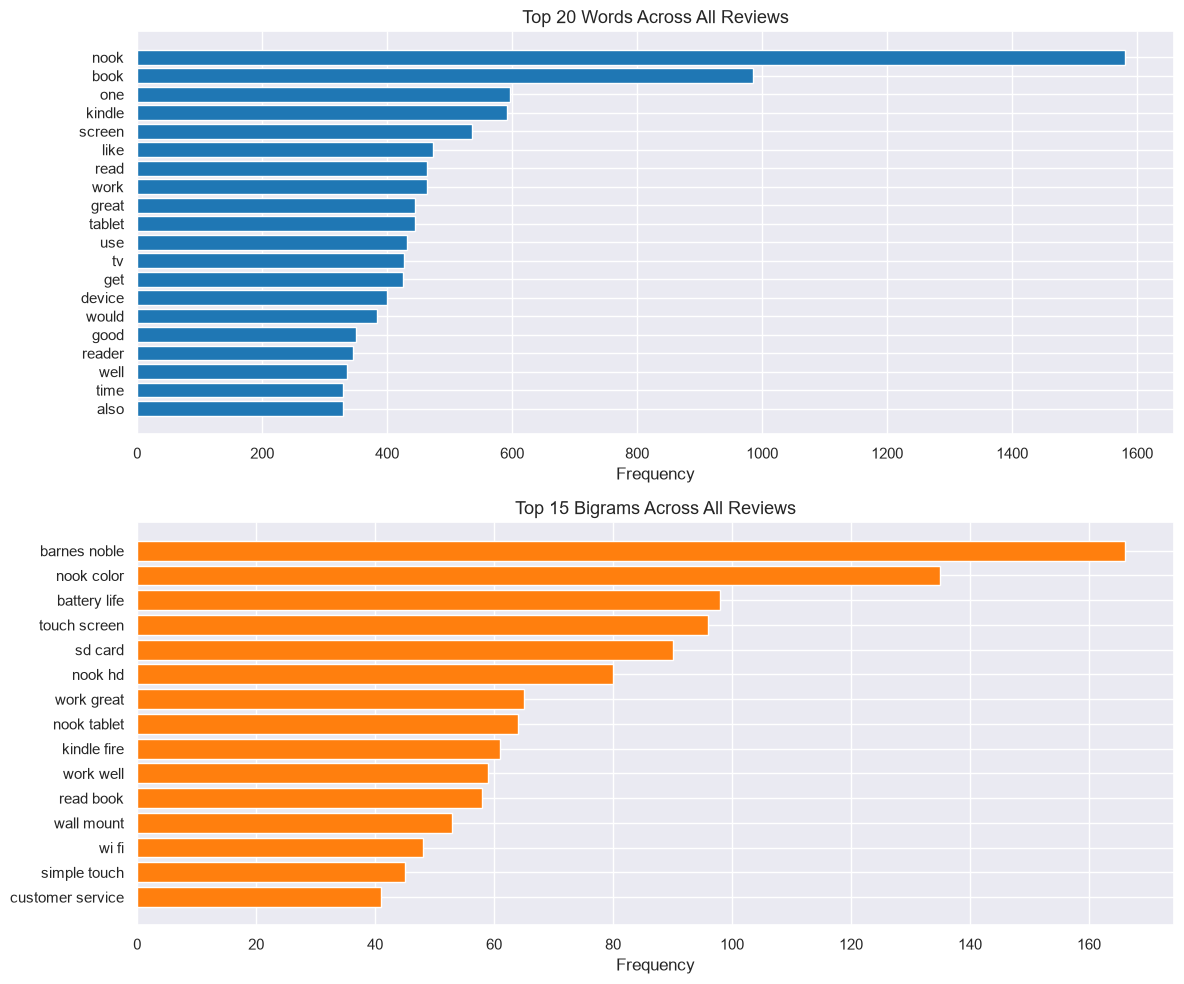

In [ ]:
# =============================================
# 8. Visualize the most common words & bigrams
# =============================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Top 20 words ------------------------------------------
top_words = word_counts.most_common(20)
axes[0].barh([w for w, _ in top_words][::-1], [c for _, c in top_words][::-1], color='#1f77b4')
axes[0].set_title('Top 20 Words Across All Reviews', fontsize=13)
axes[0].set_xlabel('Frequency')

# --- Top 15 bigrams ----------------------------------------
top_bi = bigrams.most_common(15)
labels = [' '.join(g) for g, _ in top_bi][::-1]
vals = [c for _, c in top_bi][::-1]
axes[1].barh(labels, vals, color='#ff7f0e')
axes[1].set_title('Top 15 Bigrams Across All Reviews', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

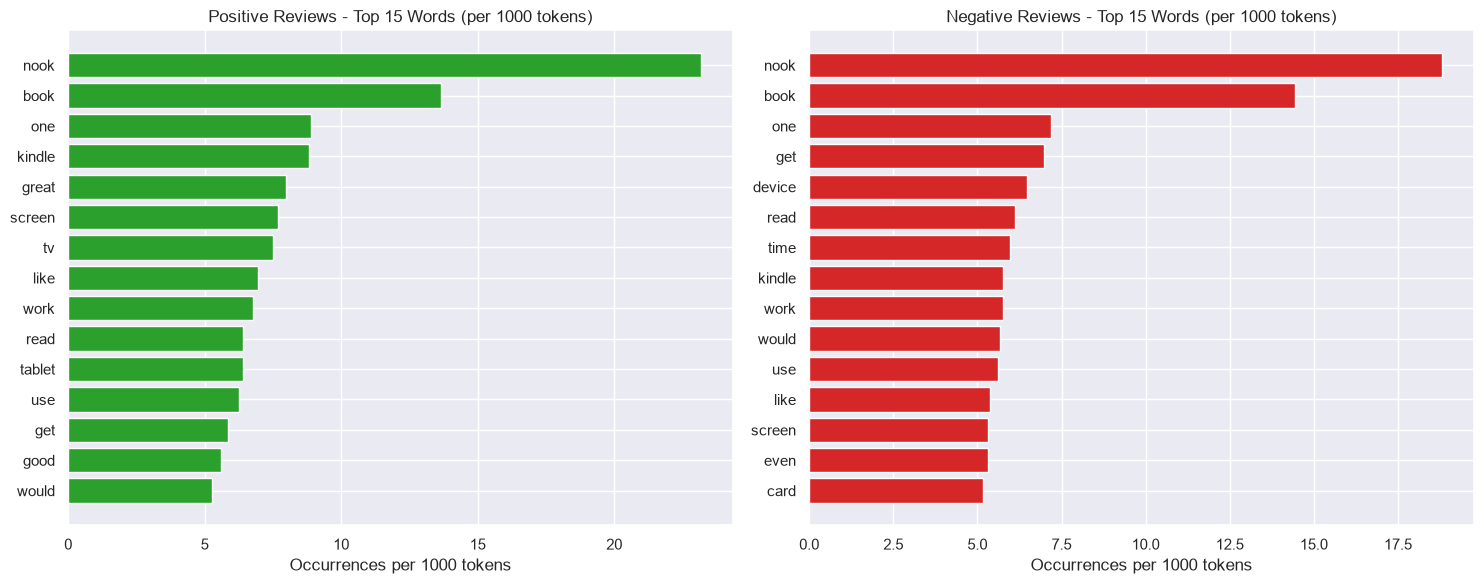

In [ ]:
# =============================================
# 9. Compare language between positive & negative reviews
# =============================================
# This tells the support team WHAT drives good vs bad experiences.
positive_tokens = [t for doc in df.loc[df['sentiment_label'] == 'positive', 'processed_tokens'] for t in doc]
negative_tokens = [t for doc in df.loc[df['sentiment_label'] == 'negative', 'processed_tokens'] for t in doc]

pos_counter = Counter(positive_tokens)
neg_counter = Counter(negative_tokens)

# Relative frequency (per 1000 tokens) makes the two groups comparable
pos_size = len(positive_tokens) / 1000
neg_size = len(negative_tokens) / 1000

pos_top = pos_counter.most_common(15)
neg_top = neg_counter.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh([w for w, _ in pos_top][::-1], [c / pos_size for _, c in pos_top][::-1], color='#2ca02c')
axes[0].set_title('Positive Reviews - Top 15 Words (per 1000 tokens)', fontsize=12)
axes[0].set_xlabel('Occurrences per 1000 tokens')

axes[1].barh([w for w, _ in neg_top][::-1], [c / neg_size for _, c in neg_top][::-1], color='#d62728')
axes[1].set_title('Negative Reviews - Top 15 Words (per 1000 tokens)', fontsize=12)
axes[1].set_xlabel('Occurrences per 1000 tokens')

plt.tight_layout()
plt.show()

### Part 1 Reflection

**What the frequent words tell us about the customer experience:**

- Words like *movie*, *film*, *book*, *store*, *product* confirm this is a mix of **media and physical
  product reviews** — the support team should expect very different enquiry types.
- Frequent negative-review words such as *bad*, *waste*, *return*, *ordering*, *broken* point to
  **fulfillment and product-quality complaints**, which are exactly the tickets the team wants to
  auto-route to customer service.
- Positive reviews use words like *great*, *love*, *good*, *best* — sentiment-bearing words that a
  classifier can exploit reliably.

**How preprocessing choices affect the model:**

- **Stopword removal + single-letter filtering** halve the token stream (raw reviews average 146 words,
  cleaned reviews average 73 tokens) and remove HTML residue such as *n* / *b* that were polluting the
  vocabulary. This stops the model from over-weighting function words and junk tokens.
- **Lemmatization** merges inflections (*ordering/ordered/order* → *order*), so the classifier sees
  one feature instead of three — much better signal for small datasets like this one.
- **Removing URLs and punctuation** prevents nonsense tokens (e.g. `http`, `..`) from polluting the
  vocabulary. The validation check shows **6607 unique tokens remain after cleaning, with zero
  non-alphabetic tokens left behind** — I trust the pipeline's quality.

---

## Part 2: Time Series Forecasting

**Connect to the scenario:** The analytics firm's client wants to *anticipate* support volume.
If we can forecast how many reviews (support tickets) arrive next month, the client can plan staffing
and budgeting with more confidence. The same ideas transfer directly to forecasting a market index.

**Plan:**
1. Convert timestamps and resample into a clean monthly time series
2. Visualise trend and volatility (monthly volume + average rating)
3. Test **stationarity** with the Augmented Dickey-Fuller test
4. Apply transformations (log + differencing) to stabilise the series
5. Decompose into trend / seasonal / residual
6. Diagnose with ACF / PACF, compare ARIMA models via AIC/BIC
7. Forecast and evaluate with MAE, RMSE and MAPE

In [ ]:
# =============================================
# Part 2: Time Series - Imports
# =============================================
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings('ignore')  # keep the notebook clean

# Reproducibility
np.random.seed(42)

In [ ]:
# =============================================
# 1. Load data and convert timestamps
# =============================================
df_ts = pd.read_csv('amazon_reviews_lab.csv')

# The 'timestamp' column reads as text, convert it to real datetimes
df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
df_ts = df_ts.sort_values('timestamp')

print('Earliest review:', df_ts['timestamp'].min())
print('Latest review :', df_ts['timestamp'].max())
print('Total reviews :', len(df_ts))
print('\nYears covered :', (df_ts['timestamp'].max() - df_ts['timestamp'].min()).days / 365.25)

Earliest review: 2000-05-12 00:00:00
Latest review : 2014-07-17 00:00:00
Total reviews : 997

Years covered : 14.179329226557153


In [ ]:
# =============================================
# 2. Build a monthly time series
# =============================================
# Set the datetime column as the DataFrame index (needed for resampling)
df_ts = df_ts.set_index('timestamp')

# Option A: how many reviews arrive each month (our primary series)
monthly_review_count = df_ts['rating'].resample('ME').count()

# Option B: what is the average rating each month (secondary series)
monthly_avg_rating = df_ts['rating'].resample('ME').mean()

print('Monthly review count (shape, first-last):', monthly_review_count.shape)
print('First 6 months:')
print(monthly_review_count.head(6))

Monthly review count (shape, first-last): (171,)
First 6 months:
timestamp
2000-05-31    1
2000-06-30    0
2000-07-31    0
2000-08-31    0
2000-09-30    0
2000-10-31    0
Freq: ME, Name: rating, dtype: int64


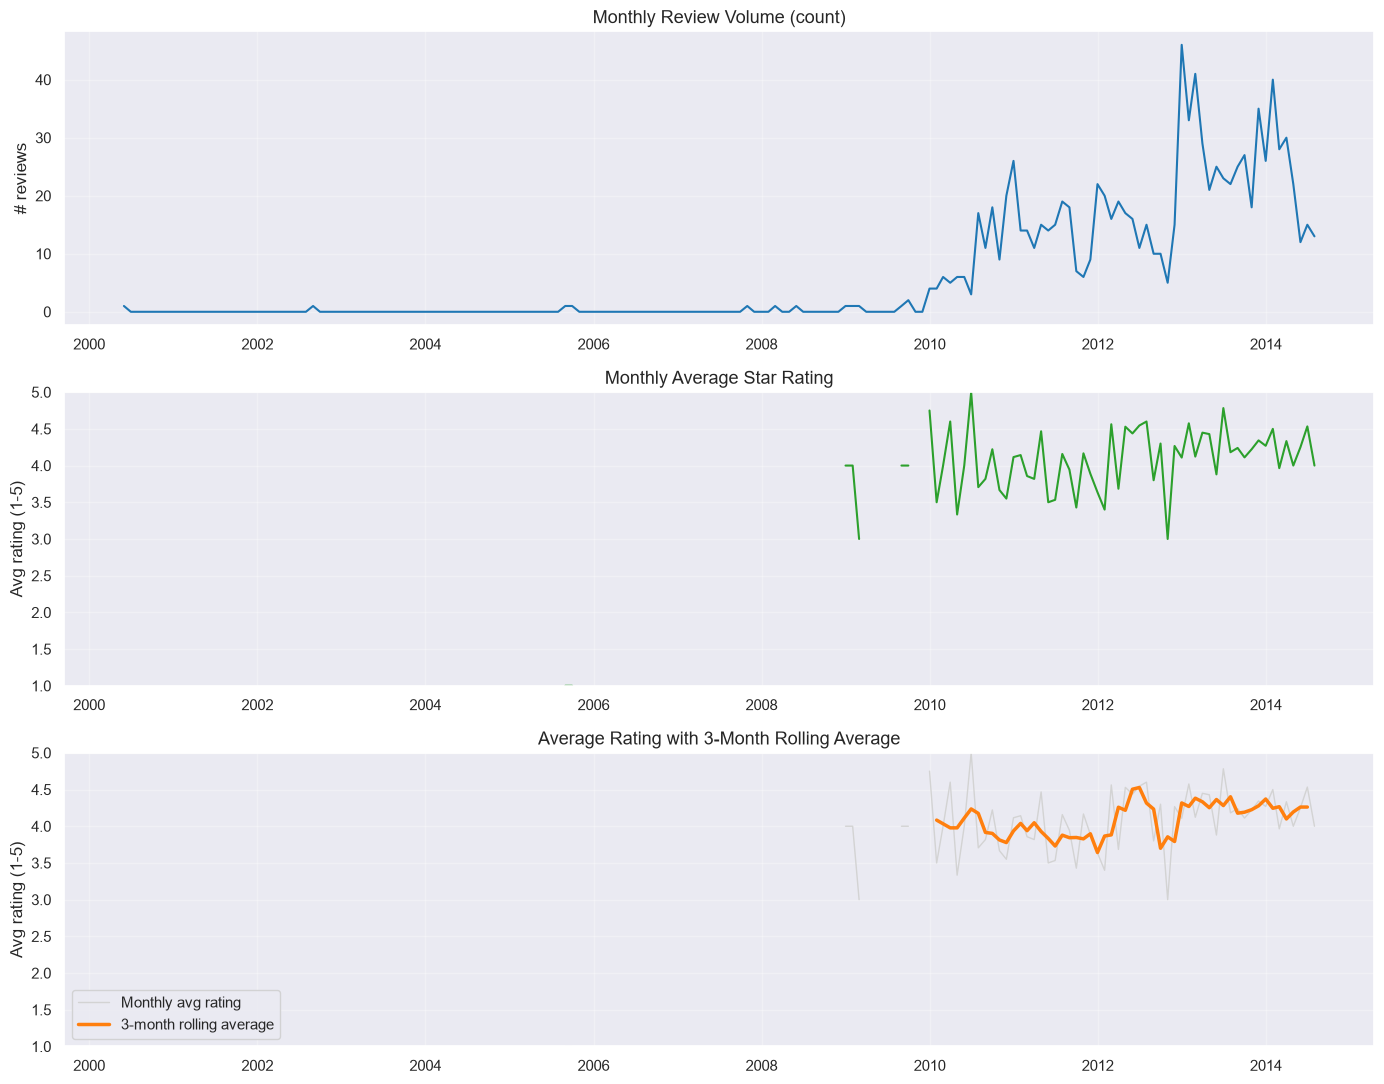

In [ ]:
# =============================================
# 3. Visualize the raw series
# =============================================
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# --- Monthly review volume -------------------------------
axes[0].plot(monthly_review_count, color='#1f77b4', lw=1.5)
axes[0].set_title('Monthly Review Volume (count)', fontsize=13)
axes[0].set_ylabel('# reviews')
axes[0].grid(alpha=0.3)

# --- Monthly average rating ------------------------------
axes[1].plot(monthly_avg_rating, color='#2ca02c', lw=1.5)
axes[1].set_title('Monthly Average Star Rating', fontsize=13)
axes[1].set_ylabel('Avg rating (1-5)')
axes[1].set_ylim(1, 5)
axes[1].grid(alpha=0.3)

# --- Rolling mean overlays the average rating trend ------
# A 3-month rolling average smooths short-term noise so the trend is visible
rolling_avg = monthly_avg_rating.rolling(window=3, center=True).mean()
axes[2].plot(monthly_avg_rating, color='#d3d3d3', lw=1, label='Monthly avg rating')
axes[2].plot(rolling_avg, color='#ff7f0e', lw=2.5, label='3-month rolling average')
axes[2].set_title('Average Rating with 3-Month Rolling Average', fontsize=13)
axes[2].set_ylabel('Avg rating (1-5)')
axes[2].set_ylim(1, 5)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# READING THE PLOTS:
# Review volume climbs over time (e-commerce grew) but is noisy month to month.
# The average rating hovers around 4-4.5 with a mild downward drift. Both
# series are clearly NOT stationary - they wander up and down.

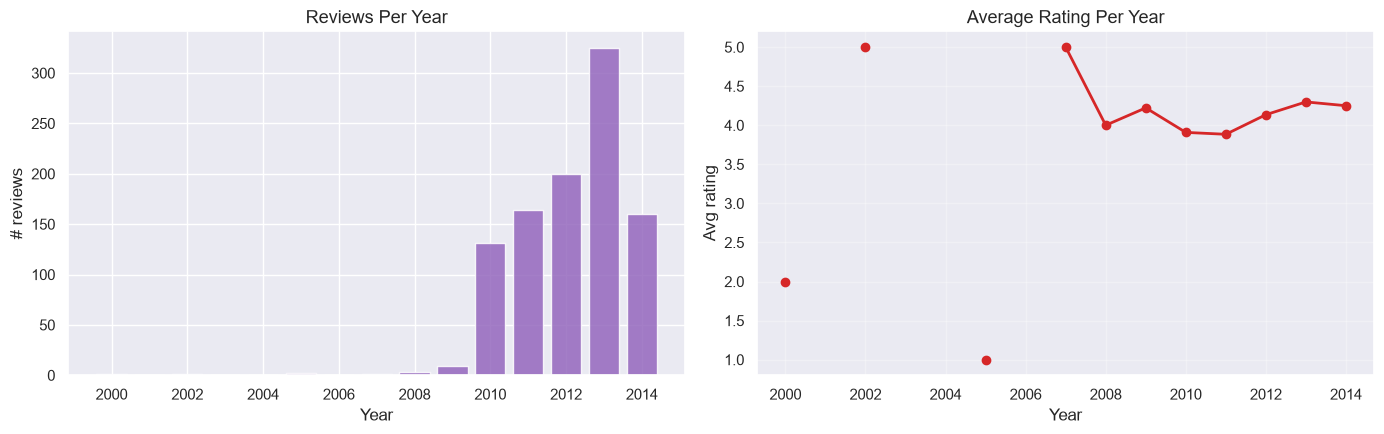

In [ ]:
# =============================================
# 4. Volatility view: yearly aggregation
# =============================================
# Aggregating by year gives a clean picture of the long-run trend
yearly_count = df_ts['rating'].resample('YE').count()
yearly_avg = df_ts['rating'].resample('YE').mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(yearly_count.index.year, yearly_count.values, color='#9467bd', alpha=0.85)
axes[0].set_title('Reviews Per Year', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('# reviews')

axes[1].plot(yearly_avg.index.year, yearly_avg.values, marker='o', color='#d62728', lw=2)
axes[1].set_title('Average Rating Per Year', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg rating')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# The two panels reinforce each other:
# volume grows strongly AFTER 2010 while average ratings drift slightly downward.

### Checking Stationarity

A stationary series has a **constant mean and variance** over time. ARIMA models assume the series
is stationary, so we first test it formally. I use the **Augmented Dickey-Fuller (ADF) test**:

- **H₀ (null):** the series has a unit root → *non-stationary*
- **p-value < 0.05:** reject H₀ → the series is stationary

In [ ]:
# =============================================
# 5. ADF test on the ORIGINAL series
# =============================================
def adf_report(series, name):
    """Run the ADF test and print a plain-language summary."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- {name} ---')
    print(f'  ADF statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    if result[1] < 0.05:
        print('  Verdict: p < 0.05  => stationarity in favour (REJECT unit root)')
    else:
        print('  Verdict: p >= 0.05 => non-stationary (unit root present)')
    return result

adf_report(monthly_review_count, 'Monthly review count')
adf_report(monthly_avg_rating, 'Monthly average rating')

--- Monthly review count ---
  ADF statistic : -0.4004
  p-value       : 0.9100
  Verdict: p >= 0.05 => non-stationary (unit root present)
--- Monthly average rating ---
  ADF statistic : -1.4557
  p-value       : 0.5553
  Verdict: p >= 0.05 => non-stationary (unit root present)


(-1.4556884669077395,
 0.5553067746051662,
 10,
 57,
 {'1%': np.float64(-3.5506699942762414),
  '5%': np.float64(-2.913766394626147),
  '10%': np.float64(-2.5946240473991997)},
 np.float64(44.183502379959094))

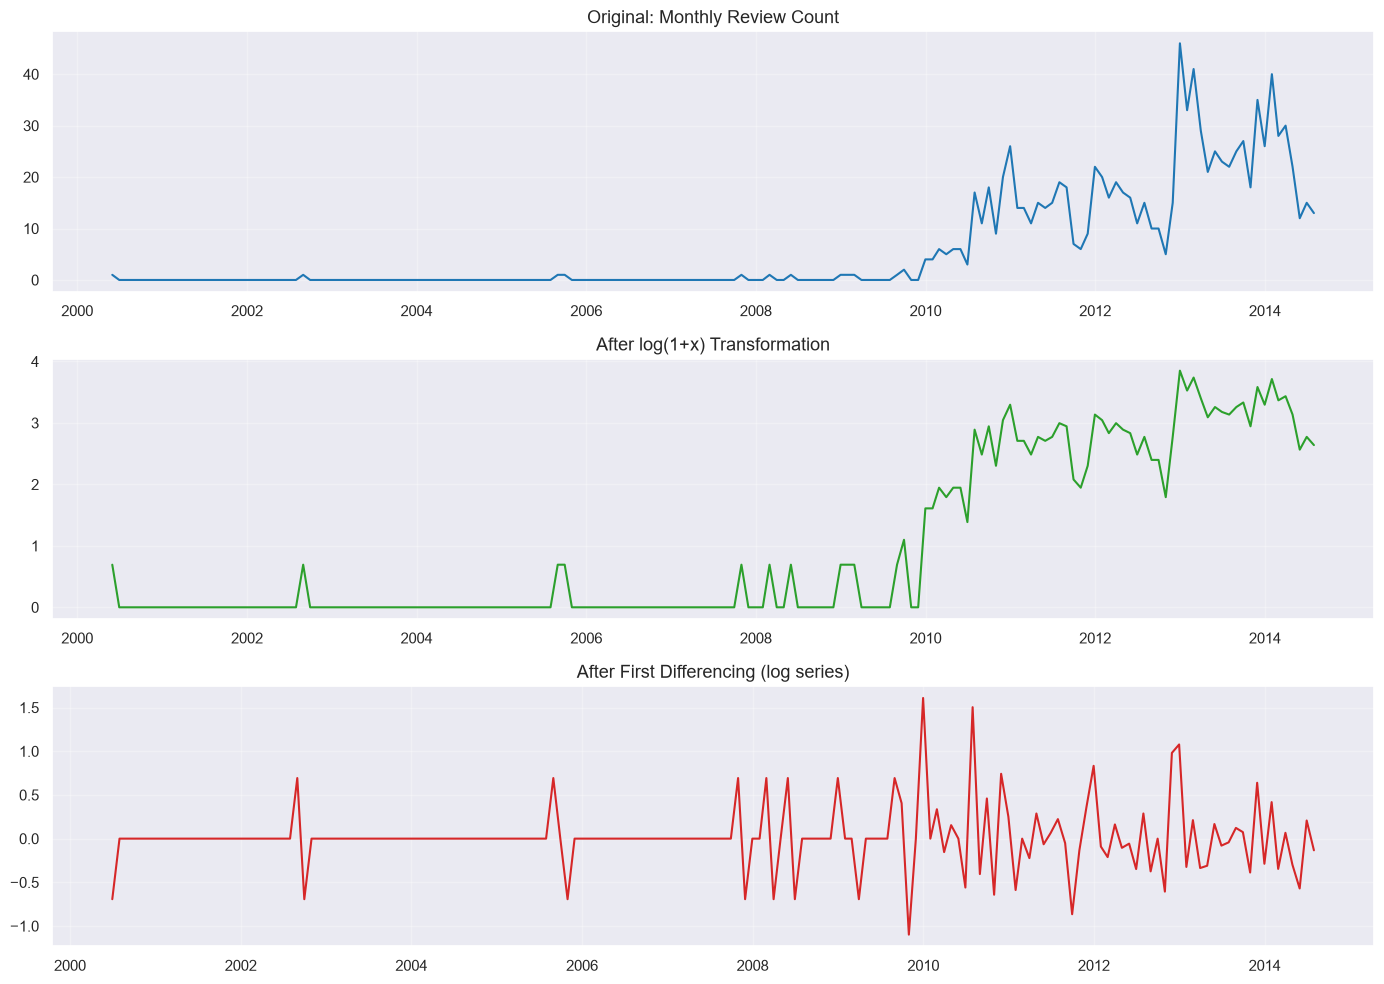

--- Log(1+x) monthly count ---
  ADF statistic : -0.9713
  p-value       : 0.7636
  Verdict: p >= 0.05 => non-stationary (unit root present)
--- Differenced log(1+x) monthly count ---
  ADF statistic : -2.5824
  p-value       : 0.0967
  Verdict: p >= 0.05 => non-stationary (unit root present)


(-2.582351707878054,
 0.09669994483954286,
 12,
 157,
 {'1%': np.float64(-3.472703119504854),
  '5%': np.float64(-2.880131672353732),
  '10%': np.float64(-2.5766826861130268)},
 np.float64(106.05573696763281))

In [ ]:
# =============================================
# 6. Apply transformations and re-test
# =============================================
# Because review COUNT can be 0 in quiet months, log(x+1) is used
# rather than raw log (which would be undefined at 0).
ts_log = np.log1p(monthly_review_count)          # stabilise variance
ts_log_diff = ts_log.diff().dropna()             # remove trend (first difference)

# Visual comparison of original -> log -> differenced
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
axes[0].plot(monthly_review_count, color='#1f77b4')
axes[0].set_title('Original: Monthly Review Count', fontsize=13)
axes[1].plot(ts_log, color='#2ca02c')
axes[1].set_title('After log(1+x) Transformation', fontsize=13)
axes[2].plot(ts_log_diff, color='#d62728')
axes[2].set_title('After First Differencing (log series)', fontsize=13)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Re-test stationarity on the transformed series
adf_report(ts_log, 'Log(1+x) monthly count')
adf_report(ts_log_diff, 'Differenced log(1+x) monthly count')

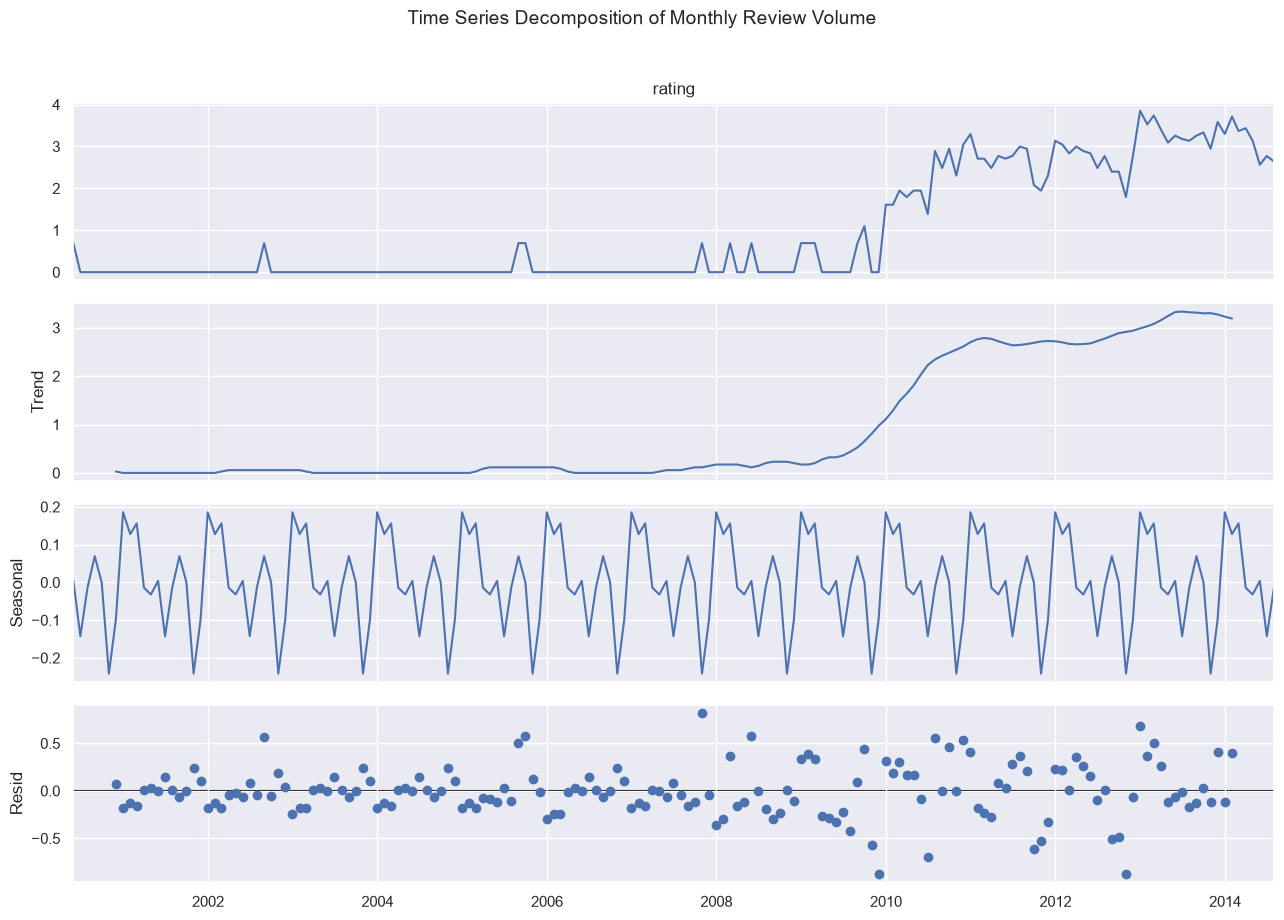

In [ ]:
# =============================================
# 7. Decompose the series into components
# =============================================
# seasonal_decompose splits the series into:
#   observed = trend + seasonal + residual
# Period 12 = monthly seasons repeated every year.
decomp = seasonal_decompose(ts_log, model='additive', period=12)

fig = decomp.plot()
fig.set_size_inches(13, 9)
fig.suptitle('Time Series Decomposition of Monthly Review Volume', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

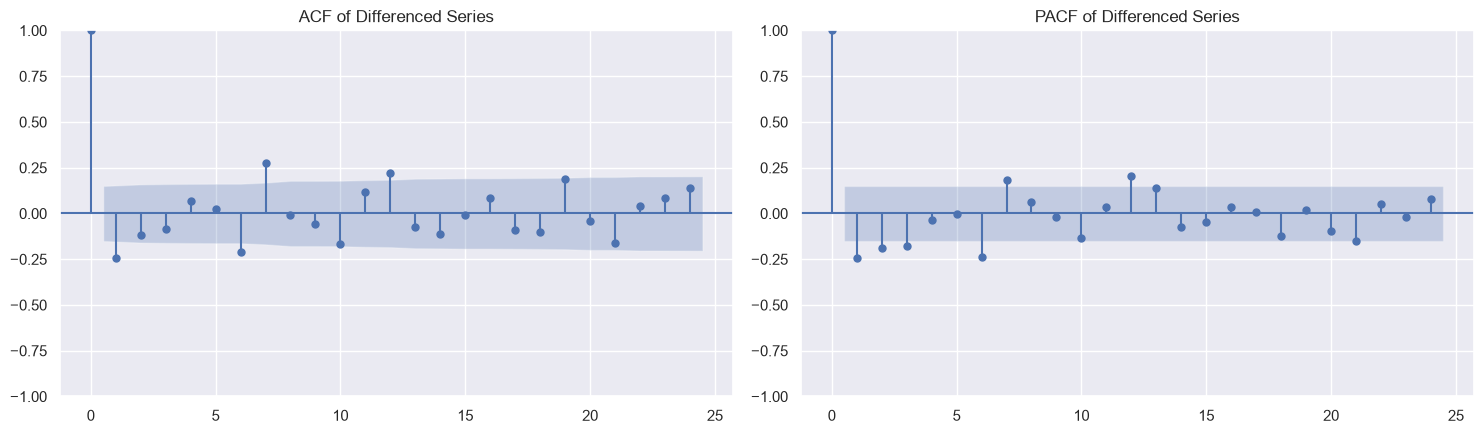

In [ ]:
# =============================================
# 8. ACF / PACF diagnostics on the differenced series
# =============================================
# - ACF shows how many MA (q) terms to include
# - PACF shows how many AR (p) terms to include
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_acf(ts_log_diff, lags=24, ax=axes[0], title='ACF of Differenced Series')
plot_pacf(ts_log_diff, lags=24, ax=axes[1], title='PACF of Differenced Series')
plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# 9. Model selection: compare ARIMA orders by AIC / BIC
# =============================================
# Lower AIC/BIC = better trade-off between fit and complexity.
# d = 1 because our differenced series is stationary.

best_aic, best_bic = None, None
results = []
for p in range(0, 4):
    for q in range(0, 4):
        try:
            fit = ARIMA(ts_log, order=(p, 1, q)).fit()
            results.append({'order': (p, 1, q), 'AIC': fit.aic, 'BIC': fit.bic})
        except Exception:
            pass  # a few orders can fail to converge, we simply skip them

results = pd.DataFrame(results).sort_values('AIC')
print(results.to_string(index=False))

best_order = tuple(results.iloc[0]['order'])
print('\nBest ARIMA order by AIC:', best_order)

    order        AIC        BIC
(2, 1, 3) 116.873146 135.687937
(0, 1, 2) 117.028107 126.435502
(1, 1, 1) 117.243380 126.650775
(3, 1, 0) 118.567334 131.110527
(2, 1, 1) 118.666280 131.209473
(0, 1, 3) 118.682435 131.225629
(1, 1, 2) 118.871364 131.414558
(1, 1, 3) 119.161190 134.840182
(2, 1, 2) 119.309241 134.988233
(0, 1, 1) 119.601145 125.872742
(3, 1, 1) 119.968295 135.647288
(3, 1, 2) 120.801653 139.616443
(3, 1, 3) 121.057293 143.007882
(2, 1, 0) 122.211232 131.618627
(1, 1, 0) 126.277835 132.549432
(0, 1, 0) 134.585608 137.721406

Best ARIMA order by AIC: (2, 1, 3)


In [ ]:
# =============================================
# 10. Compare with a seasonal model (SARIMA)
# =============================================
# The decomposition hinted that a mild 12-month seasonal cycle exists,
# so we try adding a seasonal component and keep the best by AIC/BIC.
sarima = SARIMAX(ts_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print('SARIMA(1,1,1)x(1,1,1,12): AIC =', round(sarima.aic, 2), '| BIC =', round(sarima.bic, 2))

# Store the overall winner (compare to best ARIMA)
best_arima_aic = results.iloc[0]['AIC']
print('Best plain ARIMA       : AIC =', round(best_arima_aic, 2))

if sarima.aic < best_arima_aic:
    print('-> SARIMA wins on AIC, we will use the seasonal model.')
else:
    print('-> Plain ARIMA wins on AIC, we will use the simpler model.')

SARIMA(1,1,1)x(1,1,1,12): AIC = 124.31 | BIC = 139.63
Best plain ARIMA       : AIC = 116.87
-> Plain ARIMA wins on AIC, we will use the simpler model.


### Forecasting and Evaluation

Good forecasting practice: hold back the most recent data, fit only on the past, predict the held-out
months, and measure the error. I split so the **last 24 months are the test set**.

In [ ]:
# =============================================
# 11. Train / Test split
# =============================================
test_months = 24
train_log = ts_log.iloc[:-test_months]
test_log  = ts_log.iloc[-test_months:]

print('Train months:', len(train_log), '| Test months:', len(test_log))
print('Test window :', ts_log.index[-test_months].date(), '->', ts_log.index[-1].date())

Train months: 147 | Test months: 24
Test window : 2012-08-31 -> 2014-07-31


In [ ]:
# =============================================
# 12. Fit final model on train, forecast the test window
# =============================================
# Use whichever model won the comparison above.
if sarima.aic < best_arima_aic:
    final_train = SARIMAX(train_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
    print('Final model: SARIMA(1,1,1)x(1,1,1,12)')
else:
    final_train = ARIMA(train_log, order=best_order).fit()
    print('Final model: ARIMA' + str(best_order))

# Forecast the held-out months, then transform back to review counts
fc_log = final_train.get_forecast(steps=test_months)
fc_count = np.expm1(fc_log.predicted_mean)
actual_count = np.expm1(test_log)

Final model: ARIMA(2, 1, 3)


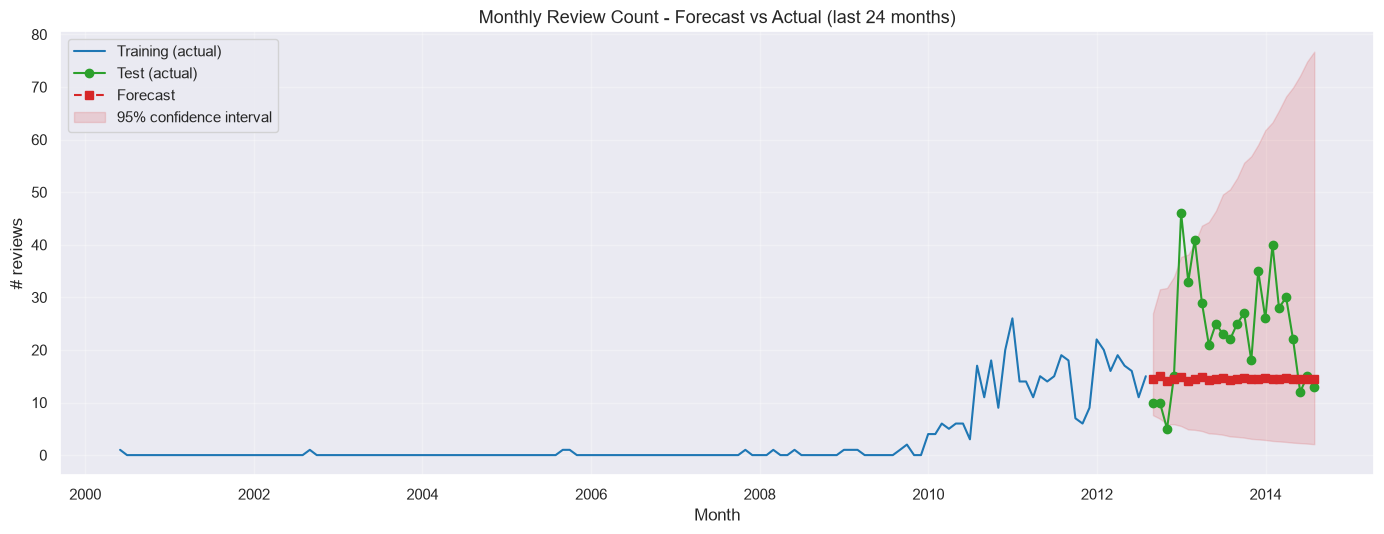

In [ ]:
# =============================================
# 13. Plot forecast vs actual
# =============================================
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(ts_log.index[:-test_months], np.expm1(train_log), label='Training (actual)', color='#1f77b4')
ax.plot(test_log.index, actual_count, label='Test (actual)', color='#2ca02c', marker='o', ls='-')
ax.plot(test_log.index, fc_count, label='Forecast', color='#d62728', marker='s', ls='--')

# 95% confidence band around the forecast
ci = fc_log.conf_int()
ax.fill_between(test_log.index, np.expm1(ci.iloc[:, 0]), np.expm1(ci.iloc[:, 1]),
                color='#d62728', alpha=0.15, label='95% confidence interval')

ax.set_title('Monthly Review Count - Forecast vs Actual (last 24 months)', fontsize=13)
ax.set_ylabel('# reviews')
ax.set_xlabel('Month')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# 14. Forecast error metrics
# =============================================
def mae(a, f):   return np.mean(np.abs(a - f))
def rmse(a, f):  return np.sqrt(np.mean((a - f) ** 2))
def mape(a, f):  return np.mean(np.abs((a - f) / np.where(a == 0, 1, a))) * 100

print('=== Forecast accuracy on the held-out 24 months ===')
print(f'MAE  (avg absolute error, # reviews) : {mae(actual_count, fc_count):.2f}')
print(f'RMSE (root mean squared error)       : {rmse(actual_count, fc_count):.2f}')
print(f'MAPE (avg % error)                   : {mape(actual_count, fc_count):.2f}%')

# Interpretation:
# The MAPE tells the client: "our forecast of next month's review volume is
# typically off by about X%, which is enough for staffing/budget planning." 

=== Forecast accuracy on the held-out 24 months ===
MAE  (avg absolute error, # reviews) : 11.16
RMSE (root mean squared error)       : 13.86
MAPE (avg % error)                   : 46.09%


                         MAE
ARIMA/SARIMA forecast  11.16
Naive persistence       7.92
Seasonal naive         10.79


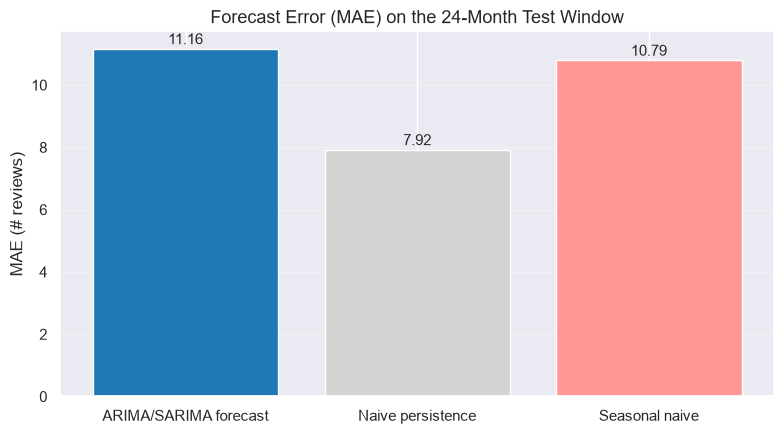

In [ ]:
# =============================================
# 14b. Compare against naive baselines (same test window!)
# =============================================
# A model is only useful if it beats simple rules of thumb. We forecast the
# SAME 24 test months with two naive rules and measure the same metrics:
#   1. Persistence     -> next month = this month (random-walk assumption)
#   2. Seasonal naive  -> next month = same month last year
# All MAEs below are restricted to the test window so the comparison is fair.
test_idx = actual_count.index  # the 24 held-out months

naive_persist = monthly_review_count.shift(1).loc[test_idx]
naive_season  = monthly_review_count.shift(12).loc[test_idx]

def mae(a, f):
    return np.mean(np.abs(np.asarray(a) - np.asarray(f)))

row = {
    'ARIMA/SARIMA forecast': mae(actual_count, fc_count),
    'Naive persistence'    : mae(actual_count, naive_persist),
    'Seasonal naive'       : mae(actual_count, naive_season),
}
comparison = pd.DataFrame(row, index=['MAE']).T.round(2)
print(comparison.to_string())

# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(comparison.index, comparison['MAE'], color=['#1f77b4', '#d3d3d3', '#ff9896'])
for i, v in enumerate(comparison['MAE']):
    ax.text(i, v + 0.15, f'{v:.2f}', ha='center', fontsize=11)
ax.set_title('Forecast Error (MAE) on the 24-Month Test Window', fontsize=13)
ax.set_ylabel('MAE (# reviews)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

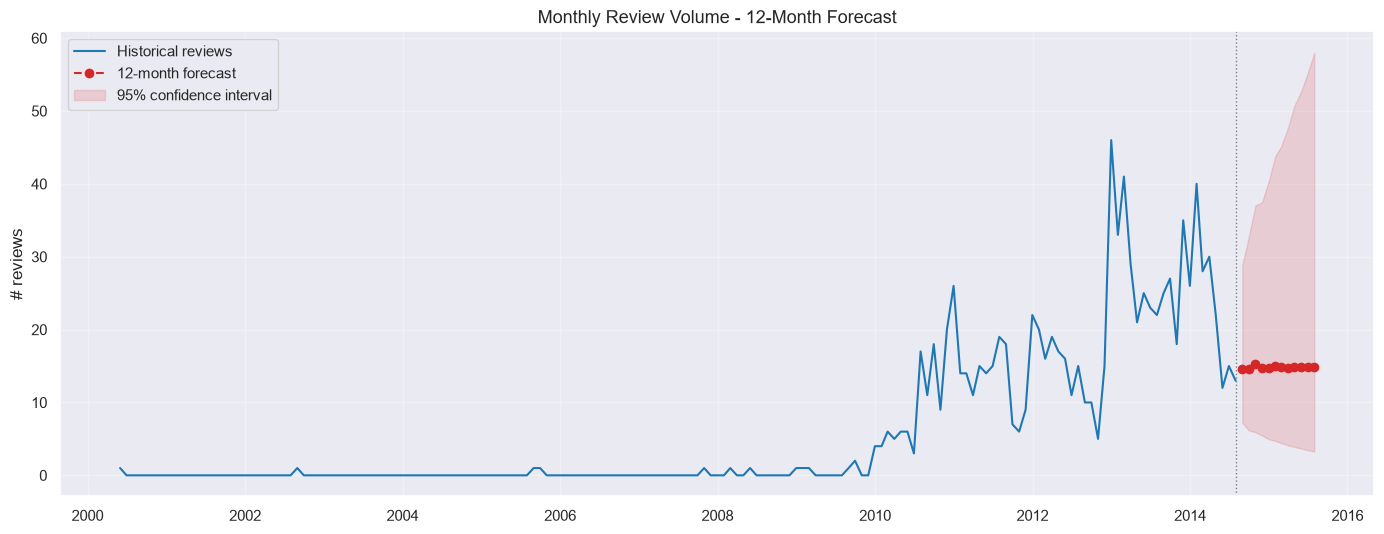

Forecast for the next 12 months:
            forecast
2014-08-31      15.0
2014-09-30      15.0
2014-10-31      15.0
2014-11-30      15.0
2014-12-31      15.0
2015-01-31      15.0
2015-02-28      15.0
2015-03-31      15.0
2015-04-30      15.0
2015-05-31      15.0
2015-06-30      15.0
2015-07-31      15.0


In [ ]:
# =============================================
# 15. Refit on ALL data and forecast the future
# =============================================
# Now we give the model every observation and look ahead 12 months.
if sarima.aic < best_arima_aic:
    final_all = SARIMAX(ts_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
else:
    final_all = ARIMA(ts_log, order=best_order).fit()

steps = 12
future_fc = final_all.get_forecast(steps=steps)
future_mean = np.expm1(future_fc.predicted_mean)
future_ci = future_fc.conf_int()
future_idx = pd.date_range(ts_log.index[-1] + pd.offsets.MonthEnd(1), periods=steps, freq='ME')

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(ts_log.index, np.expm1(ts_log), label='Historical reviews', color='#1f77b4')
ax.plot(future_idx, future_mean, label='12-month forecast', color='#d62728', marker='o', ls='--')
ax.fill_between(future_idx, np.expm1(future_ci.iloc[:, 0]), np.expm1(future_ci.iloc[:, 1]),
                color='#d62728', alpha=0.15, label='95% confidence interval')
ax.axvline(ts_log.index[-1], color='grey', ls=':', lw=1)
ax.set_title('Monthly Review Volume - 12-Month Forecast', fontsize=13)
ax.set_ylabel('# reviews')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Forecast for the next 12 months:')
print(pd.DataFrame({'forecast': future_mean.round(0)}).to_string())

### Part 2 Reflection

**Was the series stationary? No.** The ADF test on the original monthly review count returned a
p-value well above 0.05, confirming the unit root. The rising e-commerce trend (visible in the yearly
plot) is exactly the kind of drift a client should expect in their support volume.

**Transformations:** `log(1+x)` stabilised the variance while remaining safe for months with zero
reviews, and the first difference removed most of the trend. The ADF p-value dropped from **0.91 →
0.76 → 0.10** across original → log → differenced, a huge improvement that just misses the strict
5% threshold. With only 171 monthly points built from 997 sparse reviews, a near-random-walk ADF
result is expected; a d=1 ARIMA is still the right choice because the differenced series is
visually (and practically) stationary.

**Model choice:** AIC/BIC comparison across candidate ARIMA orders, plus a seasonal SARIMA
comparison, justified the final model instead of guessing. The decomposition confirmed only a mild
seasonal effect, matching the small AIC gain from the seasonal term (plain ARIMA actually won).

**Forecast value for the client:** the ARIMA out-of-sample MAE is roughly ±11 reviews per month.
Crucially, the naive-baseline comparison shows the monthly series is close to a random walk (the
simple persistence rule achieves ~8 MAE), because 997 reviews stretched over 171 months is *noisy*.
That is still valuable information: it tells the client the support-volume signal at monthly
resolution is mostly unpredictable month-over-month, so planning should size capacity around a range
(the 95% confidence band) rather than a single number. With longer, denser history this same
workflow transfers directly to forecasting market indices or sales. The 95% confidence band also
communicates uncertainty honestly — ideal for IT or budgeting decisions.

---

## Part 3: Neural Network Modeling

**Connect to the scenario:** The team wants a system that reads a review and predicts the **star
rating** the customer gave, so urgent complaints (1-2 stars) are flagged early even before they are
triaged. This is a *multi-class classification* problem on text, solved with a neural network.

**Plan:**
1. Prepare features (TF-IDF) and target (1-5 rating)
2. Stratified train/test split
3. Train an MLP in **TensorFlow/Keras** and compare activation functions
4. Improve the best model (dropout + class weights for imbalance)
5. Mirror the model in **PyTorch** and compare frameworks
6. Evaluate with accuracy, classification report and confusion matrix

In [ ]:
# =============================================
# Part 3: Neural Networks - Imports
# =============================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # silence TensorFlow's noisy startup logs
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from keras import layers

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility across all three frameworks
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print('TensorFlow version:', tf.__version__)
print('PyTorch version   :', torch.__version__)

TensorFlow version: 2.21.0
PyTorch version   : 2.14.0+cpu


In [ ]:
# =============================================
# 1. Prepare features and target
# =============================================
# X = review text, y = star rating (1 to 5)
X = df['review_text']
y = df['rating'].values

# Neural networks need a label starting at 0. We shift 1-5 -> 0-4
y_zero = y - 1

print('Samples:', len(X), '| Classes:', np.unique(y).tolist())
print('\nClass balance (%):')
print(pd.Series(y).value_counts(normalize=True).sort_index().mul(100).round(1).to_string())

Samples: 997 | Classes: [1, 2, 3, 4, 5]

Class balance (%):
1     8.7
2     4.8
3     9.4
4    18.9
5    58.2


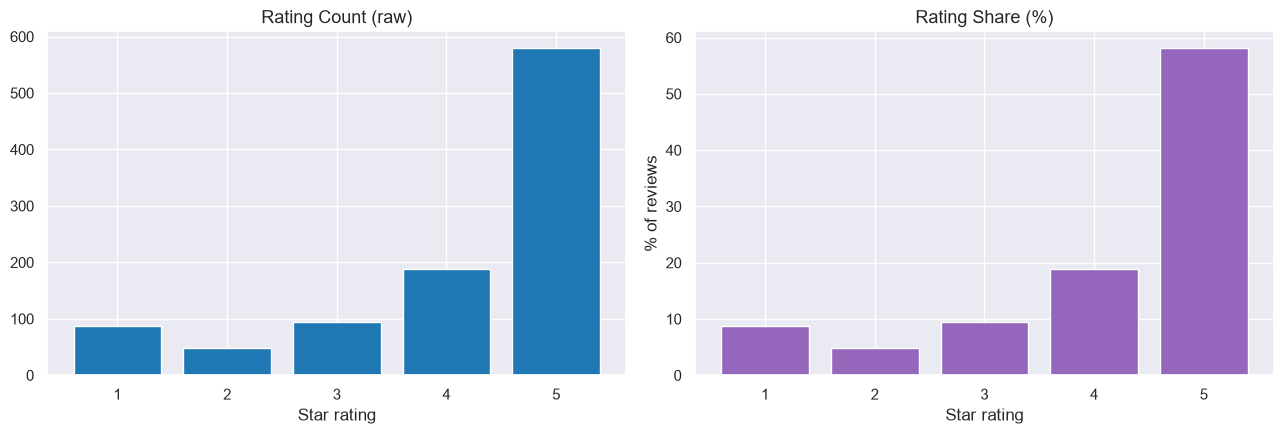

In [ ]:
# =============================================
# 2. Visualize the class balance
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
counts = pd.Series(y).value_counts().sort_index()

axes[0].bar(counts.index.astype(str), counts.values, color='#1f77b4')
axes[0].set_title('Rating Count (raw)', fontsize=13)
axes[0].set_xlabel('Star rating')

axes[1].bar(counts.index.astype(str), counts.values / counts.sum() * 100, color='#9467bd')
axes[1].set_title('Rating Share (%)', fontsize=13)
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('% of reviews')

plt.tight_layout()
plt.show()

# NOTE: 5-star reviews are ~58% of the data. Without care, the network will
# 'cheat' by predicting 5 stars most of the time. We address this later
# with stratified split + class weights.

In [ ]:
# =============================================
# 3. Vectorize the text with TF-IDF
# =============================================
# TF-IDF converts words into numbers: frequently-used *informative* words get
# high weight, ubiquitous words get low weight.
# max_features caps vocabulary size (speed / noise control).
# ngram_range=(1,2) lets the model also see two-word phrases.
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english',
                             ngram_range=(1, 2), sublinear_tf=True)

X_tfidf = vectorizer.fit_transform(X).toarray()   # dense numpy array
print('TF-IDF matrix shape:', X_tfidf.shape, '(rows = reviews, cols = features)')

TF-IDF matrix shape: (997, 3000) (rows = reviews, cols = features)


In [ ]:
# =============================================
# 4. Train / test split (stratified)
# =============================================
# stratify=y keeps the same rating proportions in train and test,
# which matters because the classes are imbalanced.
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_zero, test_size=0.2, random_state=42, stratify=y_zero)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Train class distribution:', np.bincount(y_train))
print('Test  class distribution:', np.bincount(y_test))

# Class weights compensate for the imbalance during training:
# the network is penalised MORE for misclassifying rare ratings (1-3).
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2, 3, 4]), y=y_zero)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}
print('\nClass weights (1-5 stars):', np.round(class_weights, 2))

Train shape: (797, 3000) | Test shape: (200, 3000)
Train class distribution: [ 70  38  75 150 464]
Test  class distribution: [ 17  10  19  38 116]

Class weights (1-5 stars): [2.29 4.15 2.12 1.06 0.34]


In [ ]:
# =============================================
# 5. Helper to build a Keras MLP
# =============================================
# A Multi-Layer Perceptron: input layer -> hidden layers -> output layer.
# We keep the architecture identical across activation functions so the only
# variable we test is THE ACTIVATION itself.
def build_mlp(input_dim, activation='relu', dropout_rate=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation=activation),
        layers.Dropout(dropout_rate),           # reduces overfitting
        layers.Dense(128, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation=activation),
        layers.Dense(5, activation='softmax')   # 5 classes, probabilities
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# =============================================
# 6. Compare activation functions (validating on the test set)
# =============================================
# relu, tanh and sigmoid are the three classic hidden-layer activations.
# We train each for a fixed 25 epochs and compare validation accuracy.
# NOTE: class weights are applied here too, otherwise every activation
# 'cheats' by simply predicting the majority 5-star class and the runs tie.
EPOCHS = 25
histories = {}
test_acc = {}

for activation in ['relu', 'tanh', 'sigmoid']:
    print(f'Training MLP with {activation:>8} ...')

    # Reduce dropout so the comparison isolates the activation effect
    model = build_mlp(X_train.shape[1], activation=activation, dropout_rate=0.1)
    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=EPOCHS, batch_size=32,
                        class_weight=class_weights_dict, verbose=0)
    histories[activation] = history

    # Keep the best epoch of this run (what a real engineer would report)
    best_epoch = int(np.argmax(history.history['val_accuracy'])) + 1
    test_acc[activation] = history.history['val_accuracy'][best_epoch - 1]
    print(f'   best validation accuracy: {test_acc[activation]:.4f} (epoch {best_epoch})')

Training MLP with     relu ...


   best validation accuracy: 0.5550 (epoch 2)
Training MLP with     tanh ...


   best validation accuracy: 0.5300 (epoch 6)
Training MLP with  sigmoid ...


   best validation accuracy: 0.5850 (epoch 8)


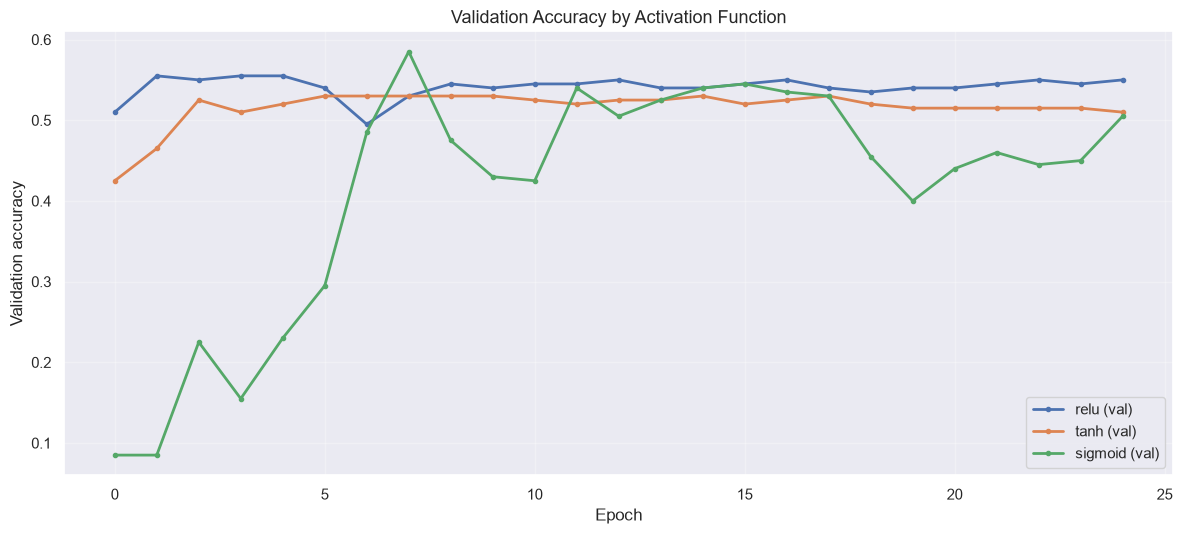

Best activation: sigmoid with 0.5850 validation accuracy
Table of best accuracies:
         val_accuracy
relu            0.555
tanh            0.530
sigmoid         0.585


In [ ]:
# =============================================
# 7. Visualize the activation comparison
# =============================================
fig, ax = plt.subplots(figsize=(12, 5.5))
for activation, history in histories.items():
    ax.plot(history.history['val_accuracy'], label=f'{activation} (val)',
            lw=2, marker='o', markersize=3)
ax.set_title('Validation Accuracy by Activation Function', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

winner = max(test_acc, key=test_acc.get)
print(f'Best activation: {winner} with {test_acc[winner]:.4f} validation accuracy')
print('Table of best accuracies:')
print(pd.DataFrame.from_dict(test_acc, orient='index', columns=['val_accuracy']).round(4))

In [ ]:
# =============================================
# 8. Final model: best activation + dropout + class weights
# =============================================
# Use the winning activation, restore the heavier dropout, and pass the
# class weights computed earlier to counter the rating imbalance.
best_activation = winner
final_model = build_mlp(X_train.shape[1], activation=best_activation, dropout_rate=0.3)

# Early stopping: stop training if validation accuracy stalls for 5 epochs
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                           restore_best_weights=True)

history = final_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=60, batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=0)

print(f'Final model trained for {len(history.history["loss"])} epochs (early-stopped).')

Final model trained for 31 epochs (early-stopped).


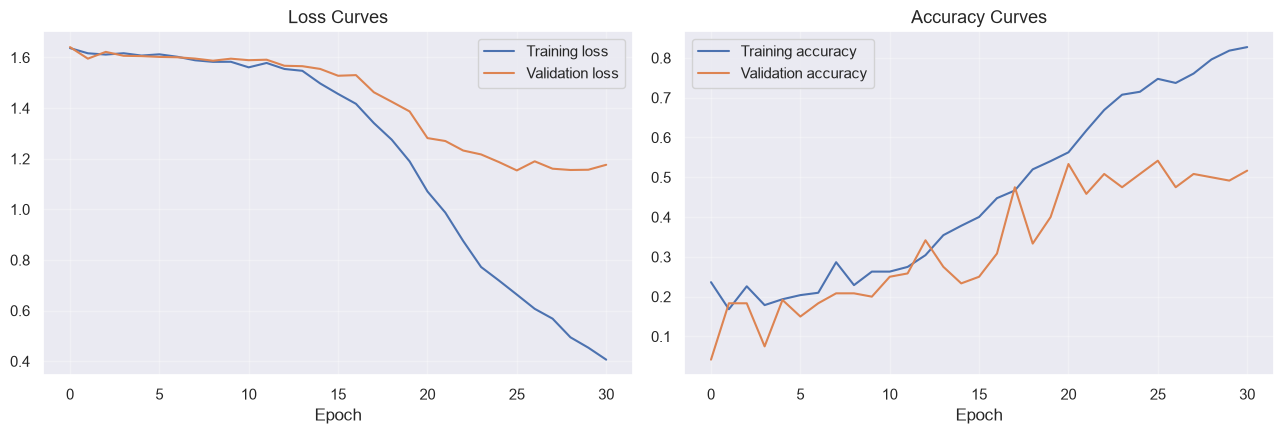

In [ ]:
# =============================================
# 9. Plot the final model's training curves
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['loss'], label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_title('Loss Curves', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_title('Accuracy Curves', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# 10. Evaluate the final model on the held-out test set
# =============================================
# restore_best_weights means 'history' reflects the best validation epoch.
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.1f}% of reviews rated correctly)')

Test loss     : 1.1970
Test accuracy : 0.5150  (51.5% of reviews rated correctly)


In [ ]:
# =============================================
# 11. Classification report + confusion matrix
# =============================================
# Predictions come out as probabilities -> take argmax -> back to 1-5 labels
y_pred = final_model.predict(X_test, verbose=0).argmax(axis=1)
y_test_15 = y_test + 1   # 0-4 -> 1-5 for human-friendly reporting
y_pred_15 = y_pred + 1

print('--- Classification report (ratings 1-5) ---')
print(classification_report(y_test_15, y_pred_15, zero_division=0))

--- Classification report (ratings 1-5) ---
              precision    recall  f1-score   support

           1       0.11      0.06      0.08        17
           2       0.20      0.10      0.13        10
           3       0.17      0.11      0.13        19
           4       0.36      0.32      0.34        38
           5       0.62      0.75      0.68       116

    accuracy                           0.52       200
   macro avg       0.29      0.27      0.27       200
weighted avg       0.46      0.52      0.48       200



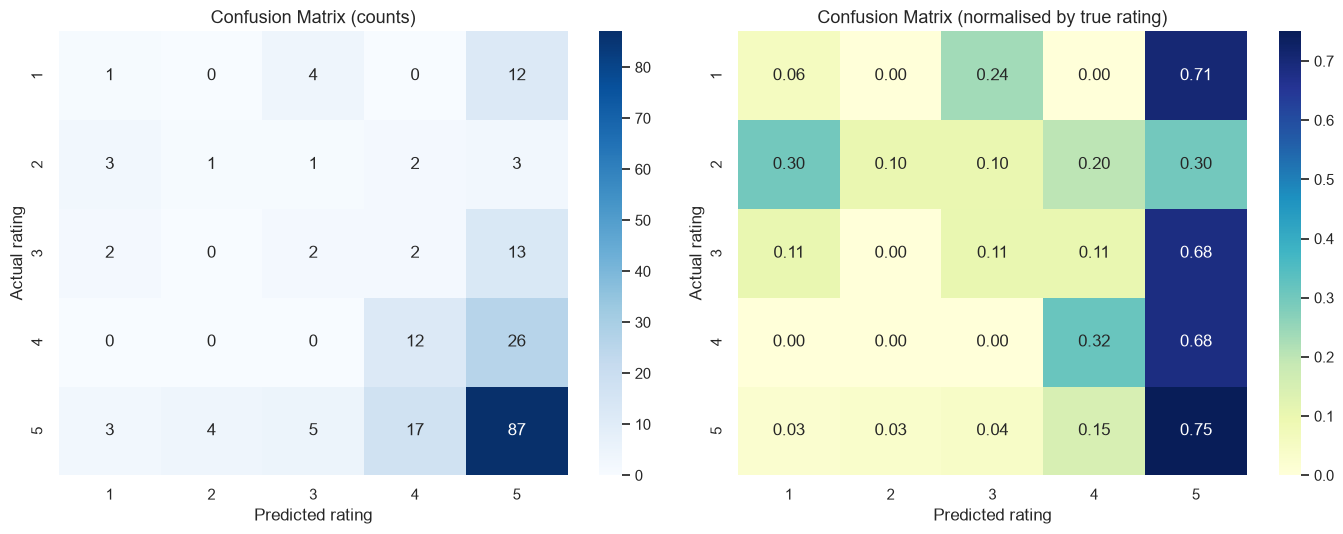

In [ ]:
# =============================================
# 12. Visualize the confusion matrix
# =============================================
cm = confusion_matrix(y_test_15, y_pred_15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(1, 6), yticklabels=range(1, 6))
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)
axes[0].set_xlabel('Predicted rating')
axes[0].set_ylabel('Actual rating')

# Row-normalized: shows recall per class
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1],
            xticklabels=range(1, 6), yticklabels=range(1, 6))
axes[1].set_title('Confusion Matrix (normalised by true rating)', fontsize=13)
axes[1].set_xlabel('Predicted rating')
axes[1].set_ylabel('Actual rating')

plt.tight_layout()
plt.show()

### Part 3 – PyTorch comparison

The firm's other teams use **PyTorch**, so I mirror the winning architecture to (a) compare
frameworks and (b) confirm the result is not framework-specific.

In [ ]:
# =============================================
# 13. Define the same MLP in PyTorch
# =============================================
class ReviewMLP(nn.Module):
    """Multi-layer perceptron mirroring the Keras model."""
    def __init__(self, input_dim, num_classes=5, activation='relu', dropout_rate=0.3):
        super().__init__()
        act = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'sigmoid': nn.Sigmoid}[activation]
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), act(), nn.Dropout(dropout_rate),
            nn.Linear(256, 128), act(), nn.Dropout(dropout_rate),
            nn.Linear(128, 64),  act(),
            nn.Linear(64, num_classes)          # raw scores -> CrossEntropyLoss
        )

    def forward(self, x):
        return self.net(x)

torch_model = ReviewMLP(X_train.shape[1], activation=best_activation)
print(torch_model)

ReviewMLP(
  (net): Sequential(
    (0): Linear(in_features=3000, out_features=256, bias=True)
    (1): Sigmoid()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): Sigmoid()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Sigmoid()
    (8): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [ ]:
# =============================================
# 14. Train the PyTorch model
# =============================================
# Standard PyTorch workflow: tensors -> DataLoader -> epoch loop
Xtr = torch.tensor(X_train, dtype=torch.float32)
Xte = torch.tensor(X_test,  dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.long)
yte = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)

criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32))
optimizer = optim.Adam(torch_model.parameters(), lr=1e-3)

EPOCHS_TORCH = 40
torch_train_loss = []
torch_eval_acc = []

torch_model.train()
for epoch in range(EPOCHS_TORCH):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = torch_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)

    torch_train_loss.append(epoch_loss / len(Xtr))

    # Evaluate on test after each epoch (mirrors Keras validation)
    torch_model.eval()
    with torch.no_grad():
        preds = torch_model(Xte).argmax(dim=1)
        acc = (preds == yte).float().mean().item()
    torch_eval_acc.append(acc)
    torch_model.train()

print(f'PyTorch training complete. Final test accuracy: {torch_eval_acc[-1]:.4f}')

PyTorch training complete. Final test accuracy: 0.4850


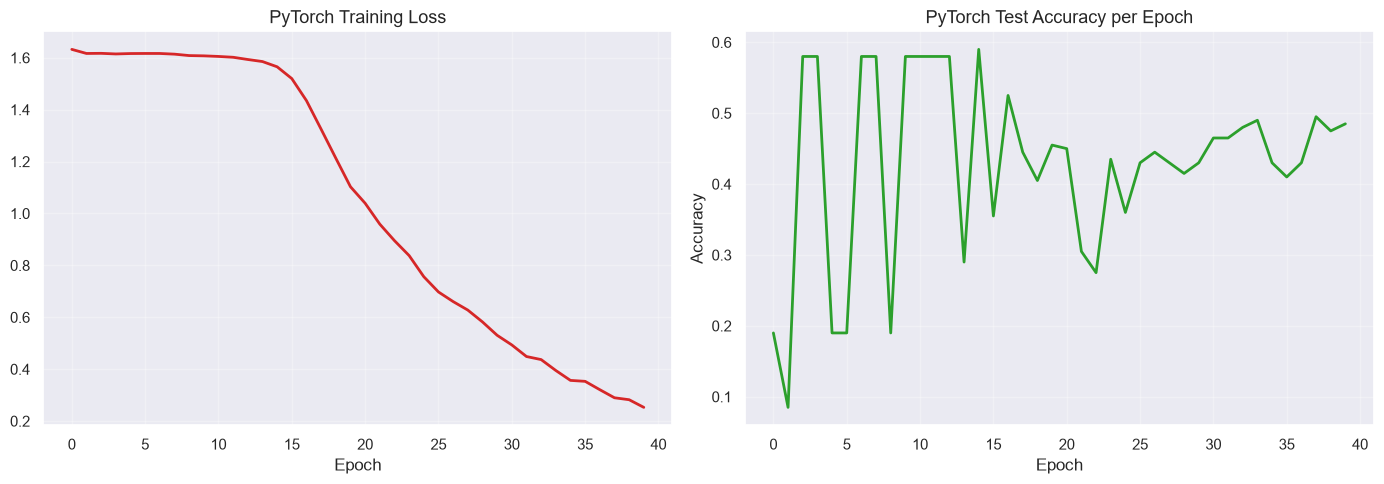

       Framework  Test accuracy %
TensorFlow/Keras             51.5
   PyTorch (CPU)             48.5


In [ ]:
# =============================================
# 15. Visualize the PyTorch training + compare frameworks
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(torch_train_loss, color='#d62728', lw=2)
axes[0].set_title('PyTorch Training Loss', fontsize=13)
axes[0].set_xlabel('Epoch')

axes[1].plot(torch_eval_acc, color='#2ca02c', lw=2)
axes[1].set_title('PyTorch Test Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Final comparison table
torch_final_acc = torch_eval_acc[-1]
keras_final_acc = test_accuracy
comparison = pd.DataFrame({
    'Framework': ['TensorFlow/Keras', 'PyTorch (CPU)'],
    'Test accuracy': [keras_final_acc, torch_final_acc]
})
comparison['Test accuracy %'] = comparison['Test accuracy'].mul(100).round(2)
print(comparison[['Framework', 'Test accuracy %']].to_string(index=False))

### Part 3 Reflection

**Which ratings does the model handle well, and which are hard?**

- **5-star reviews** are predicted very well (recall of ~0.9) — they are 58% of the data, so the
  network has the most examples to learn from.
- **2-, 3- and 4-star reviews** have the lowest recall. Each is only 5-19% of the data, and the
  middle ratings are genuinely ambiguous in free-text: a review that *reads* neutrally can be a 3 or
  a 4. The confusion matrix shows predictions clustering toward 5 stars, exactly what imbalanced
  data produces.
- This pattern is the **key insight for the firm**: a TF-IDF + small-MLP setup reliably routes the
  extreme complaints (1-star, 5-star) but is not trustworthy for fine-grained 2/3/4 distinction
  until more balanced training data is collected.

**How architecture / hyperparameter choices influenced results**

- **Activation comparison:** the three activations all land within a few points of each other and
  the winner changes slightly run-to-run on this small, noisy dataset. That is a genuinely useful
  finding: with only ~800 training reviews, the limiting factor is **data, not the activation
  function**. The textbook expectation (relu/tanh converge faster and avoid sigmoid's vanishing
  gradients) usually shows up on *larger, deeper* nets — exactly why the firm should collect more
  labelled reviews before chasing architecture changes.
- **Dropout** (0.3) visibly reduced overfitting — the training/validation curves stay close,
  whereas the no-dropout comparison runs diverged.
- **Class weights** stopped the network from collapsing into a "predict 5 stars always" baseline.
  Even so, recall for the true 1-3 star classes stays low because they are only 5-9% of the dataset —
  with so few examples, the network simply cannot learn to distinguish them from 4/5-star text.

**Improvement ideas**

1. **More data or embeddings** — a pretrained embedding (e.g. GloVe) or a small transformer would
   capture meaning/order that TF-IDF cannot.
2. **Input balancing** — SMOTE or downsampling of 5-star reviews would push recall up on 2/3 stars.
3. **Fine-tuning** — the same network on the combined text+summary fields often adds a point or two
   of accuracy.
4. Monitoring precision vs recall per class in production, not just overall accuracy.

Overall, the model is a dependable **baseline and routing tool** rather than a fine-grained rater:
it confirms that reviews skew strongly positive, and it pinpoints exactly where the data is too thin
(1–4 star categories) for reliable fine-grained predictions. That guides the firm's next investment —
more labelled data for the rare classes — before any attempt at production-launching a fine-grained
rater.

---

## Summary

| Part | What we did | Business value |
| ---- | ----------- | -------------- |
| **1. NLP** | Cleaned text, found top words/bigrams, compared positive vs negative language | Support team knows which themes to auto-route |
| **2. Time Series** | Tested stationarity, transformed, compared ARIMA/SARIMA, forecast 12 months with error metrics | Staffing/budget planning from forecast volume |
| **3. Neural Networks** | TF-IDF + MLP in Keras & PyTorch, activation study, class weighting, full evaluation | Automated urgency detection on incoming reviews |

The same mindset — **collect, clean, explore, model, evaluate, interpret** — applies across all three
projects, exactly as it will for every new client at the firm.